# Simulation Dataset Analysis Workflow
This notebook contains a sample workflow for analyzing a galaxy simulation dataset. 

First I import scientific computing and data analysis packages, along with tools I have developed and released for analyzing our simulation datasets.

In [ ]:
# Scientific computing and data analysis
import numpy as np
from silx.io.dictdump import dicttoh5, h5todict
from astropy import units as un, constants as cons

# Project-specific tools I built
import iht
from scripts.halo_analysis_scripts import *

# Data visualization
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.patheffects as mppe
from matplotlib.patches import Annulus
from cmcrameri import cm as cmsci
import smplotlib

from firestudio.studios.gas_studio import GasStudio
from firestudio.studios.star_studio import StarStudio

# Notebook plotting settings
%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 22,
})

## 1. Load in the dataset
First I load the dataset into memory. The dataset is about 10GB, and is stored in multiple HDF5 files.

I use a function from my library, `load_allparticles`, to load the particle types (e.g., gas, dark matter, stars) and columns (e.g., position coordinates and velocities) needed for the analysis.

In [2]:
simulation_path = '/projects/b1026/snapshots/metal_diffusion/cr_heating_fix/m12i_r7100'

In [3]:
!du -sh {simulation_path}/output/snapdir_600

9.6G	/projects/b1026/snapshots/metal_diffusion/cr_heating_fix/m12i_r7100/output/snapdir_600


In [4]:
!h5ls -r {simulation_path}/output/snapdir_600/snapshot_600.0.hdf5

/                        Group
/Header                  Group
/PartType0               Group
/PartType0/Acceleration  Dataset {13813026, 3}
/PartType0/Coordinates   Dataset {13813026, 3}
/PartType0/Density       Dataset {13813026}
/PartType0/ElectronAbundance Dataset {13813026}
/PartType0/InternalEnergy Dataset {13813026}
/PartType0/Masses        Dataset {13813026}
/PartType0/Metallicity   Dataset {13813026, 15}
/PartType0/NeutralHydrogenAbundance Dataset {13813026}
/PartType0/ParticleChildIDsNumber Dataset {13813026}
/PartType0/ParticleIDGenerationNumber Dataset {13813026}
/PartType0/ParticleIDs   Dataset {13813026}
/PartType0/Potential     Dataset {13813026}
/PartType0/SmoothingLength Dataset {13813026}
/PartType0/StarFormationRate Dataset {13813026}
/PartType0/Velocities    Dataset {13813026, 3}
/PartType1               Group
/PartType1/Acceleration  Dataset {17614434, 3}
/PartType1/Coordinates   Dataset {17614434, 3}
/PartType1/Masses        Dataset {17614434}
/PartType1/ParticleCh

In [5]:
keys_to_extract = {
    0:['Coordinates', 'Masses', 'Density', 
    'Temperature', 'InternalEnergy', 'CosmicRayEnergy', 
    'Velocities', 'Metallicity', 'SoundSpeed', 'CoolingRate', 'SmoothingLength', 
    'MagneticField', 'ParticleIDs', 'StarFormationRate', 'NeutralHydrogenAbundance'],
    1:['Coordinates', 'Masses', 'Velocities'],
    2:['Coordinates', 'Masses', 'Velocities'],
    4:['Coordinates', 'Masses', 'Velocities', 'ParticleIDs', 'Metallicity', 'StellarFormationTime'],
    5:['Coordinates', 'Masses', 'Velocities']
}

simulation_data = load_allparticles(simulation_path, 600, [0,1,2,4,5], 
                                    keys_to_extract=keys_to_extract, 
                                    loud=False)

## 2. Transform the coordinates and calculate additional quantities

Next I use functions from my `iht` library to transform the coordinates to the center of mass frame of the galaxy halo, and align the xy-plane with the plane of the galactic disk.

I also calculate additional quantities needed for this analysis, namely the density of Hydrogen gas $n_H$, and the gas entropy $K$.

In [6]:
pos_center_of_mass = iht.halo_center_wrapper(simulation_data[1])
vel_center_of_mass = iht.velocity_COM(simulation_data)

In [7]:
# Shift coordinates to center of mass frame
for k in simulation_data.keys():
    simulation_data[k]['Coordinates'] -= pos_center_of_mass
    simulation_data[k]['Velocities'] -= vel_center_of_mass

# Rotate coordinates to disk axis
iht.rotate_coords(simulation_data, simulation_data[4]['Rvir'])

In [8]:
# Calculate gas properties: density nH and entropy K
XH = 1 - simulation_data[0]['Metallicity'][:,0] - simulation_data[0]['Metallicity'][:,1] #hydrogen mass fraction
nH = ( XH * (simulation_data[0]['Density'] * 1e10 * un.Msun/un.kpc**3) / cons.m_p ).to(un.cm**-3) #number density of hydrogen atoms
K = (cons.k_B 
      * simulation_data[0]['Temperature'] * un.K 
      / (simulation_data[0]['Density'] * 1e10 * un.Msun / un.kpc**3 
         / (0.62 * cons.m_p))**(2/3))

simulation_data[0]['nH'] = nH.to(un.cm**-3).value
simulation_data[0]['K'] = K.to(un.keV * un.cm**2).value

## 3. Visualize the dataset

It is helpful to visualize the data we are working with. I create a 2D histogram of the mass-weighted temperature of the gas that is inside a 200 kpc cube of the center of the galaxy.

In [9]:
# Select the gas particles that are found within a 200 kpc cube of the galaxy.
xs,ys,zs = simulation_data[0]['Coordinates'].T
gas_mask = (np.abs(xs) < 200) & (np.abs(ys) < 200) & (np.abs(zs) < 200)

print(f'{gas_mask.sum():,} gas particles within the mask')

9,079,818 gas particles within the mask


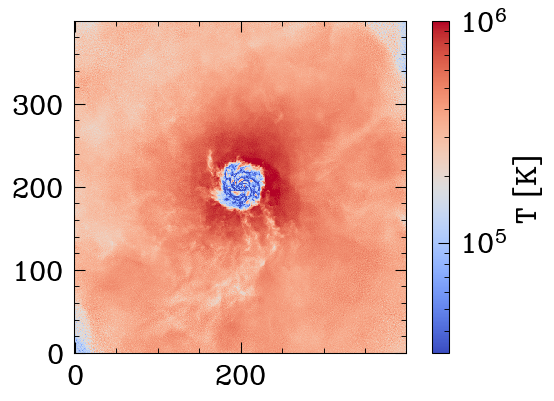

In [11]:
# Plot a temperature map of the gas particles.
from matplotlib.colors import LogNorm

h_mt,xedges,yedges = np.histogram2d(
    xs[gas_mask],
    ys[gas_mask],
    bins=400,
    weights=simulation_data[0]['Masses'][gas_mask]*simulation_data[0]['Temperature'][gas_mask])

h_m,xedges,yedges = np.histogram2d(
    xs[gas_mask],
    ys[gas_mask],
    bins=400,
    weights=simulation_data[0]['Masses'][gas_mask])

plt.imshow((h_mt/h_m).T, cmap=plt.get_cmap('coolwarm'), norm=LogNorm(vmin=10**4.5,vmax=1e6))
plt.gca().set_aspect(1)
plt.colorbar(label='T [K]');

The visualization reveals 'cold' gas near the center (which resides in the galaxy), and much hotter gas surrounding the galaxy (the "halo" of the galaxy). 

More advanced visualizations I produced for this analysis using a custom visualization library are at the end of the notebook.

## 4. Quantitative analysis of the gas in the halo

I am interested in the properties of the hot gaseous halo, such as its temperature and density. I begin by selecting the hot gas particles, computing average quantities and histograms, and caching the resuts to disk.

In [12]:
def cache_profiles( part, output_file_name, temperature_min=1e5, rbins=None ):
    '''
    Computes and stores average properties of gas particles (temperature, density, and entropy):
    Radially-averaged profiles of these quantities as a function of radius, 
    and 2D histograms of the quantities over radius.
    
    The results are stored to a structured HDF5 file `output_file_name`.
    '''
    def make_colormap(p, k, krange, f=1, rrange=(0, 3), log=True, bins=100):
        '''Helper function that computes a 2D histogram of quantity k over radius.'''
        idx = inrange( p['r_scaled']*p['Rvir'], np.power(10, rrange) )
        Mtest = f*p[k][idx]
        if log: Mtest = np.log10(Mtest)

        rtest = np.log10(p['r_scaled'][idx]*p['Rvir'])
        hrange = [[rtest.min(), rtest.max()],krange]

        H, xedges, yedges = np.histogram2d(rtest, Mtest, bins=bins, range=hrange, density=True, weights=p['Masses'][idx])
        X, Y = np.meshgrid(xedges, yedges)
        H = H.T

        for i in range(H.shape[1]):
            H[:,i] = H[:,i] / np.sum(H[:,i])

        return {'X':X, 'Y':Y, 'H':H}
    
    p0 = part[0] # Convenient dict for all gas particles
    
    # Default radial shells for the measurements
    if rbins is None:
        rbins = np.power(10, np.arange(np.log10(0.005258639741921723), np.log10(3), 0.05))
    rmid = (rbins[:-1]+rbins[1:])/2 #in units of Rvir
    
    # Make a cut on particles below the given temperature
    Tmask = p0['Temperature'] > temperature_min
    
    profiles = {
        'T':[],
        'nH':[],
        'K':[]
    }

    # Compute profiles in radial shells
    for r0,r1 in zip(rbins[:-1],rbins[1:]):
        idx = np.flatnonzero(Tmask & inrange( p0['r_scaled'], (r0, r1) ))
        V = np.sum(p0['Vi'][idx]) #volume of shell in physical kpc^3

        # Temperature profile: log <T/K>
        Tavg = np.sum(p0['Temperature'][idx] * p0['Vi'][idx]) / V
        profiles['T'].append(np.log10(Tavg))

        # nH profile: log <nH/cm^-3>
        nHavg = np.sum(p0['nH'][idx] * p0['Vi'][idx]) / V
        profiles['nH'].append(np.log10(nHavg))
        
        # Entropy profile: log <K/(keV cm^2))>
        Kavg = np.sum(p0['K'][idx] * p0['Vi'][idx]) / V
        profiles['K'].append(np.log10(Kavg))
        
    # Convert profiles to NumPy arrays
    for k,v in profiles.items(): profiles[k] = np.array(v)
    
    cache = {**profiles, 
             'rmid': rmid,
             'cmap_nH':make_colormap( p0, 'nH', (-7,1) ),
             'cmap_T': make_colormap( p0, 'Temperature', (3,8) ),
             'cmap_K': make_colormap( p0, 'K', (0.25,2.5) ),
             'Rvir' : p0['Rvir']
            }
        
    # Write results to disk
    dicttoh5(cache, output_file_name)

I run the calculations and cache the results to a file `simulation_cache.h5`. Note this file is significantly smaller than the raw simulation dataset, which was almost 10 GB.

In [13]:
cache_profiles(simulation_data, 'simulation_cache.h5')

In [14]:
!h5ls simulation_cache.h5

K                        Dataset {55}
Rvir                     Dataset {SCALAR}
T                        Dataset {55}
cmap_K                   Group
cmap_T                   Group
cmap_nH                  Group
nH                       Dataset {55}
rmid                     Dataset {55}


In [16]:
!du -h simulation_cache.h5

736K	simulation_cache.h5


Finally, I load in my small structured dataset, and make a plot of the results for **temperature, density, and entropy**.

In [17]:
# Load small dataset of calculated results to memory
simulation_cache = h5todict('simulation_cache.h5')

In [18]:
def makecoolingflow(Sims, fname=None, rmin=0.07, rmax=1.2, cbar=True):
    '''
    Plots the radially-averaged profiles and 2D histograms.
    '''
    def colormap(k, ax, sim, Rvir=1, un=1):
        '''Helper function to draw a given 2D histogram'''
        d = sim[f'cmap_{k}']
        im = ax.pcolormesh(np.log10(10**d['X']/Rvir), d['Y']+ np.log10(un), d['H'], cmap='inferno', norm=colors.LogNorm(vmin=10**-3.4, vmax=1, clip=True), rasterized=True)
        return im
    def getoutline(linewidth=2):
        '''Helper function to add an outline effect to lines'''
        patheff = [mppe.Stroke(linewidth=linewidth + 0.5, foreground="black"),mppe.Normal()]
        return patheff

    ylabels = [r'$\log \left[ n_H / \mathrm{cm}^{-3} \right]$', 
            '$\\log \\left[ T / \\mathrm{K} \\right]$',
            r'$\log \left[ K/(keV\ cm^2) \right]$'
            ]

    prolabels = ['nH', 'T','K']
    
    fig, axes = plt.subplots(len(ylabels), len(Sims), sharex=True, sharey='row', gridspec_kw={'wspace': .05, 'hspace':.09}, figsize=[4.8*len(Sims),3.2*len(ylabels)], dpi=150, facecolor='w', squeeze=False)
    
    for mi,Sim in enumerate(Sims):
        pro = Sim
        rmid = pro['rmid']*pro['Rvir']
        
        axes[-1,mi].set_xlabel(r'$\log (r/R_{vir})$')

        # Add profile curves
        for ax, ylabel, prolabel in zip(axes[:,mi], ylabels, prolabels):
            ax.set_xlim(np.log10(rmin),np.log10(rmax))
            ax.plot(np.log10(rmid/pro['Rvir']), pro[prolabel], '--', label='avg.', lw=2, c='w',  path_effects=getoutline())

            if mi==0: ax.set_ylabel(ylabel)
            ax.tick_params(colors='white', which='both', labelcolor='k')
        
        axes[0,0].set_ylim(-6, -0.5)
        axes[1,0].set_ylim(3,8)
        axes[2,0].set_ylim(.25, 2.5)
        
        # Add FIRE-3 colormaps
        im = colormap('nH', axes[0,mi], Sim, pro['Rvir'])
        colormap('T', axes[1,mi], Sim, pro['Rvir'])
        colormap('K', axes[2,mi], Sim, pro['Rvir'])
    
    if cbar:
        # Add the colorbar to the figure
        cbar_ax = fig.add_axes([0.92, (1-0.5)/2, 0.02, 0.5]) # [left, bottom, width, height]
        cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
        cbar.set_label('radial shell mass fraction')
    
    axes[0,-1].legend(loc=1, labelcolor='w',frameon=True, facecolor="white", framealpha=0.3)
    fig.tight_layout()
    if fname: plt.savefig(fname, bbox_inches='tight')
    return fig, axes

(<Figure size 720x1440 with 4 Axes>,
 array([[<AxesSubplot:ylabel='$\\log \\left[ n_H / \\mathrm{cm}^{-3} \\right]$'>],
        [<AxesSubplot:ylabel='$\\log \\left[ T / \\mathrm{K} \\right]$'>],
        [<AxesSubplot:xlabel='$\\log (r/R_{vir})$', ylabel='$\\log \\left[ K/(keV\\ cm^2) \\right]$'>]],
       dtype=object))

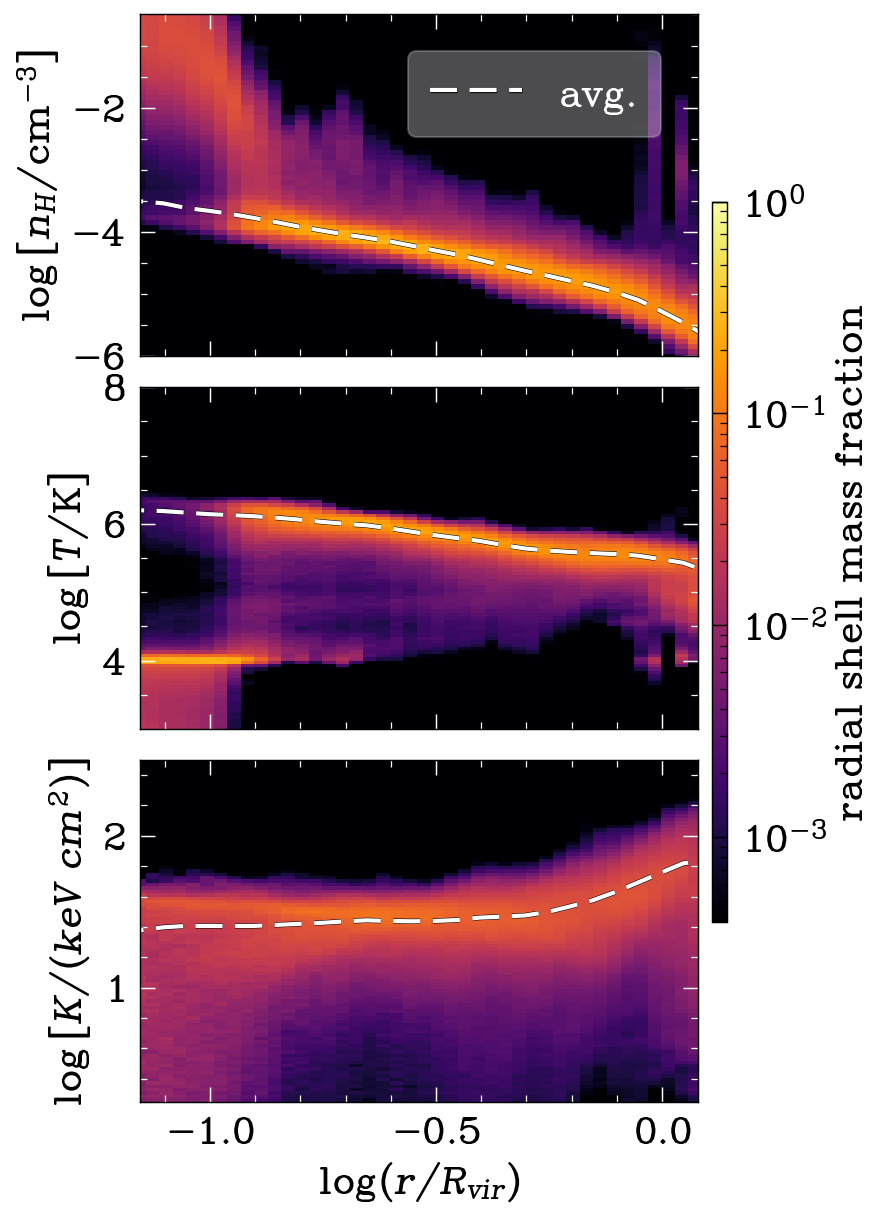

In [19]:
makecoolingflow([simulation_cache])

A useful validation check is that the average profiles are consistent with the bright regions of the histogram that trace the hot gas.

## 5. Fitting analytic models to the dataset

At this stage, I commonly fit analytic models to the radial profiles above calculated from the simulation data. Comparing models based on different physical assumptions helps identify which processes shape the halo’s gas structure and where those assumptions break down.

Below are the results of fitting four analytic models in our study, Sultan et al. 2025. I wrote functions to fit the cooling-flow model across a suite of 30 simulations using parameter sweeps to identify the best fit parameters.

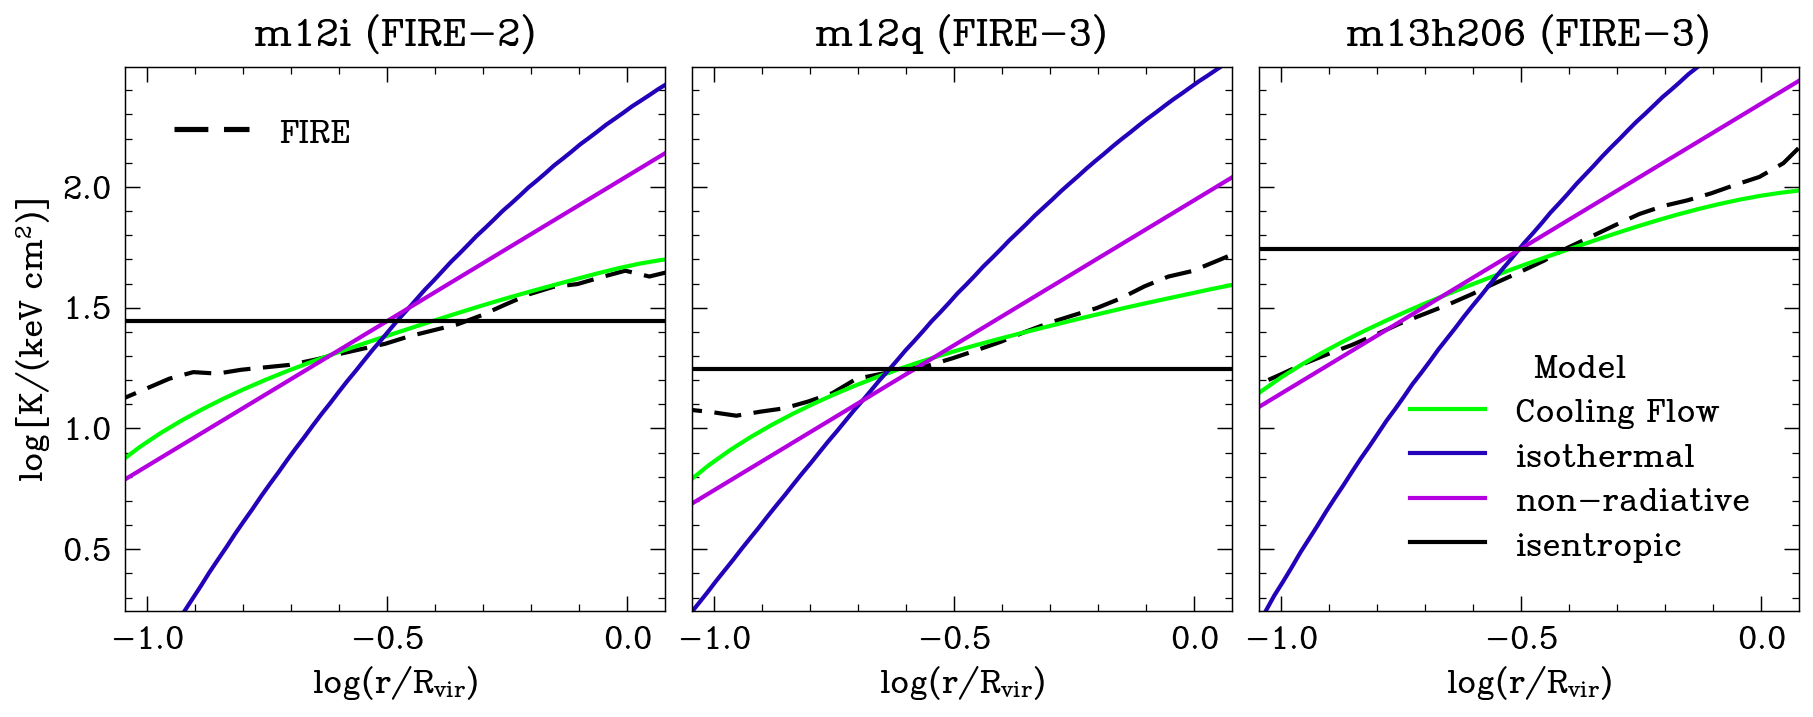

In [38]:
Kf = (cons.k_B * un.K / un.cm**3 / (1e10 * un.Msun / un.kpc**3)**(5/3) / (CF.mu*cons.m_p)**(-5/3) ).to(un.keV*un.cm**2).value
fig, axes = plt.subplots(1, 3, sharex=True, sharey=True, gridspec_kw={'wspace': .05, 'hspace':.05}, figsize=[4.8*3,4.8*1], dpi=150)

axes[0].plot([], [], 'k--', label='FIRE', lw=2.5)
axes[0].legend()

shifts = {PaperSimNames['m12m_fire2_NoBH']:   (-2, 13.8, 13.7, 13.2),
          PaperSimNames['m12i_fire2_NoBH']:   (-2, 13.8, 13.7, 13.2),
          PaperSimNames['m12a_NoBH']:   (-2, 13.8, 13.65, 13.3),
          PaperSimNames['m12q_NoBH']:   (-2, 13.7, 13.50, 13),
          PaperSimNames['m13h113_NoBH']:(-2, 14.1, 13.85, 13.5),
          PaperSimNames['m13h206_NoBH']:(-2.5, 14.1, 13.8, 13.5)}

for ax, k in zip( axes, ['m12i_fire2_NoBH', 'm12q_NoBH', 'm13h206_NoBH'] ):
    Sim = res_cf[k]
    res = Sim.mb_solution_fitting_turb
    ax.plot(np.log10(Sim.pro['rmid']), Sim.pro['Kn'], 'k--', lw=2)
    ax.plot(np.log10(res.Rs().to(un.kpc).value/Sim.pro['Rvir']), np.log10(res.Ks().value), '-', label=f'Cooling Flow', lw=2, c='lime')
    x, K = K_isothermal(Sim)
    
    s1, s2, s3, s4 = shifts[Sim.simname]
    
    ax.plot(x, K+s1 + np.log10(Kf), label='isothermal', lw=2)
    
    ax.plot(x, 1.2*x + s2 + np.log10(Kf), label='non-radiative', lw=2)
    
    
    ax.axhline(s4 + np.log10(Kf), label='isentropic', lw=2)
    
    ax.set_xlabel(r'$\log (r/R_{vir})$')
    ax.set_title(plottitles[k])


axes[-1].legend(title='Model')

axes[0].set_xlim(np.log10(0.09), np.log10(1.2))
axes[0].set_ylim(12 + np.log10(Kf), 14.25 + np.log10(Kf))
axes[0].set_ylabel(r'$\log \left[ K/(keV\ cm^2) \right]$')
plt.savefig('../Paper1Figs/KSlopes_rep.pdf')

## 6. Advanced visualizations

As part of my analysis workflows, I created more advanced visualizations for publication using our custom library FIRE Studio and an object-oriented API I built. Below are two examples. The first is similar to the gas temperature map in Section 3. The second shows more detailed renderings of the gas and stars in the simulated galaxy.

In [ ]:
from scripts.GalaxyViz import Galaxy
from firestudio.utils.camera_utils import Camera as Camera

projecting 11380600 particles
------------------------------------------
------------------------------------------
minmax(weightMap) 0.0 0.0053038937
Fraction deposited: 0.99999905
minmax(weightWeightedQuantityMap) 0.0 0.0
-done
min_logT =  3.5
max_logT =  6
Image range (logT):  1.9110568 6.0018344
Image range (8bit):  0.0 255.0


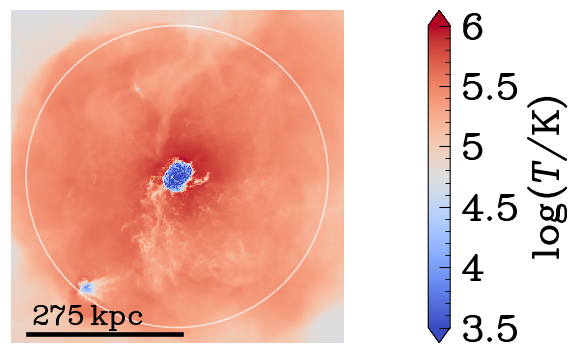

In [140]:
accretionmodes_gasmap(gal, plt.gca())

projecting 4985358 particles
------------------------------------------
------------------------------------------
minmax(weightMap) 0.0 0.005934014
Fraction deposited: 0.9999996
minmax(weightWeightedQuantityMap) 0.0 0.0
-done
min_Masses =  -3
max_Masses =  1.6
Image range (Masses):  -inf 2.2275047
Image range (8bit):  0.0 255.0
projecting 2773084 particles
------------------------------------------
------------------------------------------
minmax(weightMap) 0.0 0.00025385662
Fraction deposited: 0.99999994
minmax(weightWeightedQuantityMap) 0.0 0.0
-done
min_Masses =  -1.25
max_Masses =  3
Image range (Masses):  -inf 3.1086216
Image range (8bit):  0.0 255.0
setting color_scheme_nasa to user value of: True
setting maxden to user value of: None
setting dynrange to user value of: None
setting noaxis to user value of: True
setting camera to user value of: Camera(pos=array([ 0.,  0., 15.]),focus=array([0, 0, 0]))
setting scale_bar to user value of: True
setting scale_line_length to user val

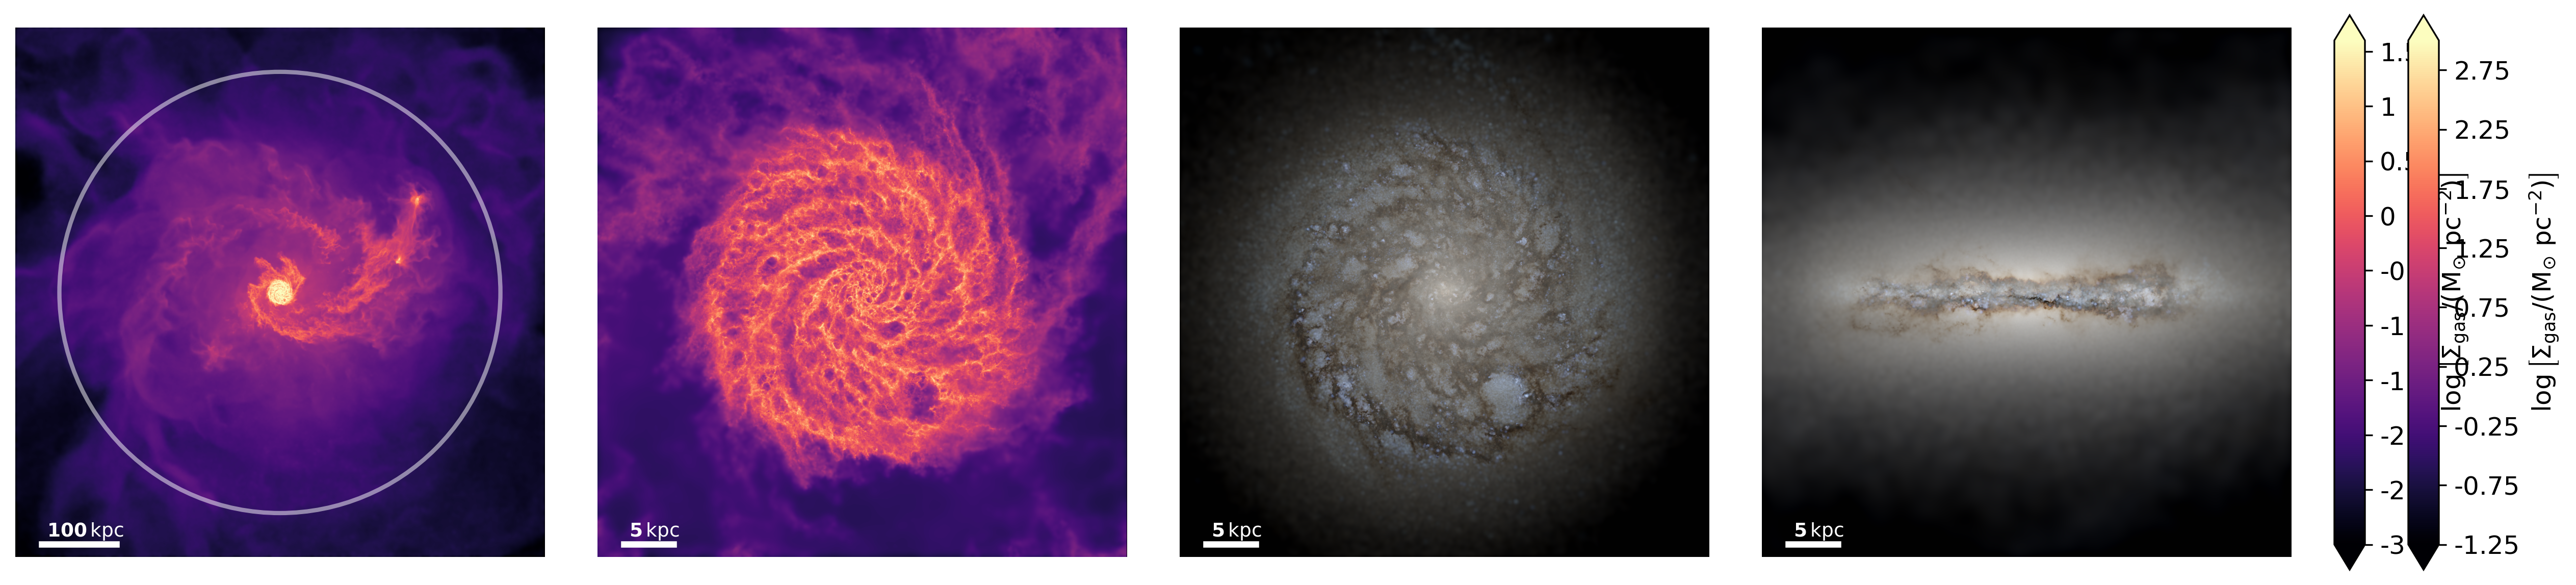

In [7]:
fig, axes = plt.subplots(1, 4, dpi=300, 
                         figsize=[4.8*4,4.8*1], 
                         gridspec_kw={'wspace': .1, 'hspace':.1})

FIREmanyscales(gal, *axes)